# Stress Testing and Scenario Analysis

In this notebook, we evaluate how different portfolio allocations behave under adverse market scenarios.

The analysis includes:

- custom stress scenarios
- historical stress periods
- maximum drawdown analysis

The objective is to understand how Conservative, Balanced, and Aggressive portfolios react during unfavorable market conditions.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Project folders
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
IMAGES_DIR = PROJECT_ROOT / "images"

OUTPUTS_DIR.mkdir(exist_ok=True)
IMAGES_DIR.mkdir(exist_ok=True)

# Load daily returns
returns = pd.read_csv(
    DATA_DIR / "daily_returns.csv",
    index_col=0,
    parse_dates=True
)

returns.head()

,GLD,QQQ,SPY,TLT
Date,,,,
2018-01-03,-0.002637,0.009717,0.006325,0.004782
2018-01-04,0.005127,0.001749,0.004215,-0.000159
2018-01-05,-0.001036,0.010043,0.006664,-0.002856
2018-01-08,-0.000160,0.003891,0.001829,-0.000637
2018-01-09,-0.004628,0.000062,0.002264,-0.013372


In [2]:
# Portfolio allocations
portfolios = {
    "Conservative": {
        "SPY": 0.20,
        "QQQ": 0.10,
        "TLT": 0.50,
        "GLD": 0.20
    },
    "Balanced": {
        "SPY": 0.40,
        "QQQ": 0.30,
        "TLT": 0.20,
        "GLD": 0.10
    },
    "Aggressive": {
        "SPY": 0.50,
        "QQQ": 0.40,
        "TLT": 0.05,
        "GLD": 0.05
    }
}

assets = returns.columns
initial_portfolio_value = 10_000

portfolios

{'Conservative': {'SPY': 0.2, 'QQQ': 0.1, 'TLT': 0.5, 'GLD': 0.2},
 'Balanced': {'SPY': 0.4, 'QQQ': 0.3, 'TLT': 0.2, 'GLD': 0.1},
 'Aggressive': {'SPY': 0.5, 'QQQ': 0.4, 'TLT': 0.05, 'GLD': 0.05}}

## Custom Stress Scenarios

We define several hypothetical market shock scenarios to evaluate portfolio sensitivity to adverse conditions.

In [3]:
# Custom stress scenarios
stress_scenarios = pd.DataFrame({
    "Market Crash": {
        "SPY": -0.20,
        "QQQ": -0.25,
        "TLT": 0.05,
        "GLD": 0.05
    },
    "Tech Sell-Off": {
        "SPY": -0.15,
        "QQQ": -0.30,
        "TLT": 0.03,
        "GLD": 0.02
    },
    "Rate Shock": {
        "SPY": -0.08,
        "QQQ": -0.10,
        "TLT": -0.20,
        "GLD": -0.05
    },
    "Inflation Shock": {
        "SPY": -0.05,
        "QQQ": -0.08,
        "TLT": -0.12,
        "GLD": 0.10
    }
}).T

# Reorder columns to match returns
stress_scenarios = stress_scenarios[assets]

stress_scenarios

,GLD,QQQ,SPY,TLT
Market Crash,0.05,-0.25,-0.20,0.05
Tech Sell-Off,0.02,-0.30,-0.15,0.03
Rate Shock,-0.05,-0.10,-0.08,-0.20
Inflation Shock,0.10,-0.08,-0.05,-0.12


In [4]:
# Calculate portfolio returns under each stress scenario
stress_results = pd.DataFrame(index=stress_scenarios.index)

for portfolio_name, allocation in portfolios.items():
    weights = pd.Series(allocation)
    weights = weights[assets]

    stress_results[portfolio_name] = stress_scenarios.dot(weights)

stress_value_results = initial_portfolio_value * (1 + stress_results)

# Save results
stress_results.to_csv(OUTPUTS_DIR / "custom_stress_test_returns.csv")
stress_value_results.to_csv(OUTPUTS_DIR / "custom_stress_test_values.csv")

stress_results

,Conservative,Balanced,Aggressive
Market Crash,-0.030,-0.140,-0.1950
Tech Sell-Off,-0.041,-0.142,-0.1925
Rate Shock,-0.136,-0.107,-0.0925
Inflation Shock,-0.058,-0.058,-0.0580


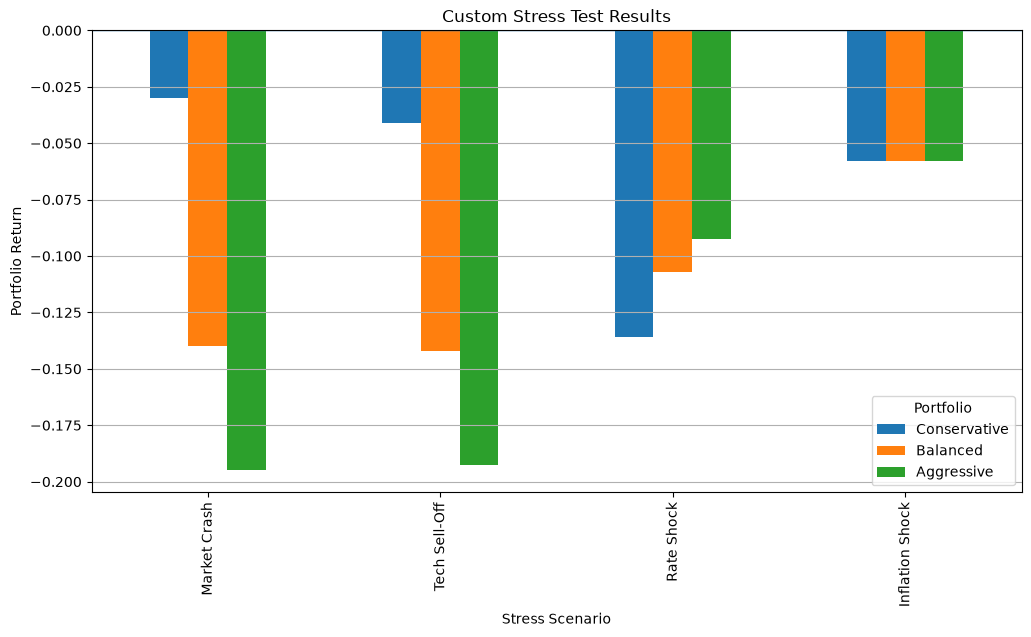

In [5]:
ax = stress_results.plot(kind="bar", figsize=(12, 6))

plt.title("Custom Stress Test Results")
plt.xlabel("Stress Scenario")
plt.ylabel("Portfolio Return")
plt.axhline(0, linewidth=1)
plt.grid(axis="y")
plt.legend(title="Portfolio")

fig = ax.get_figure()
fig.savefig(IMAGES_DIR / "custom_stress_test_results.png", dpi=300, bbox_inches="tight")

plt.show()

## Maximum Drawdown Analysis

Maximum drawdown measures the largest peak-to-trough decline in portfolio value over a given period.

This metric helps evaluate how much an investor could have lost during the worst historical decline.

In [6]:
# Calculate daily portfolio returns for each portfolio
portfolio_daily_returns = pd.DataFrame(index=returns.index)

for portfolio_name, allocation in portfolios.items():
    weights = pd.Series(allocation)
    weights = weights[assets]

    portfolio_daily_returns[portfolio_name] = returns.dot(weights)

portfolio_daily_returns.head()

,Conservative,Balanced,Aggressive
Date,,,
2018-01-03,0.004100,0.006138,0.007157
2018-01-04,0.001964,0.002692,0.003056
2018-01-05,0.000702,0.005004,0.007155
2018-01-08,0.000404,0.001755,0.002431
2018-01-09,-0.007153,-0.002213,0.000256


In [7]:
# Calculate cumulative portfolio values
portfolio_values = initial_portfolio_value * (1 + portfolio_daily_returns).cumprod()

# Calculate running maximum values
running_max = portfolio_values.cummax()

# Calculate drawdowns
drawdowns = portfolio_values / running_max - 1

# Maximum drawdown summary
max_drawdown_summary = drawdowns.min().to_frame(name="Maximum Drawdown")

# Save results
max_drawdown_summary.to_csv(OUTPUTS_DIR / "maximum_drawdown_summary.csv")
drawdowns.to_csv(OUTPUTS_DIR / "portfolio_drawdowns.csv")

max_drawdown_summary

,Maximum Drawdown
Conservative,-0.274029
Balanced,-0.273791
Aggressive,-0.282048


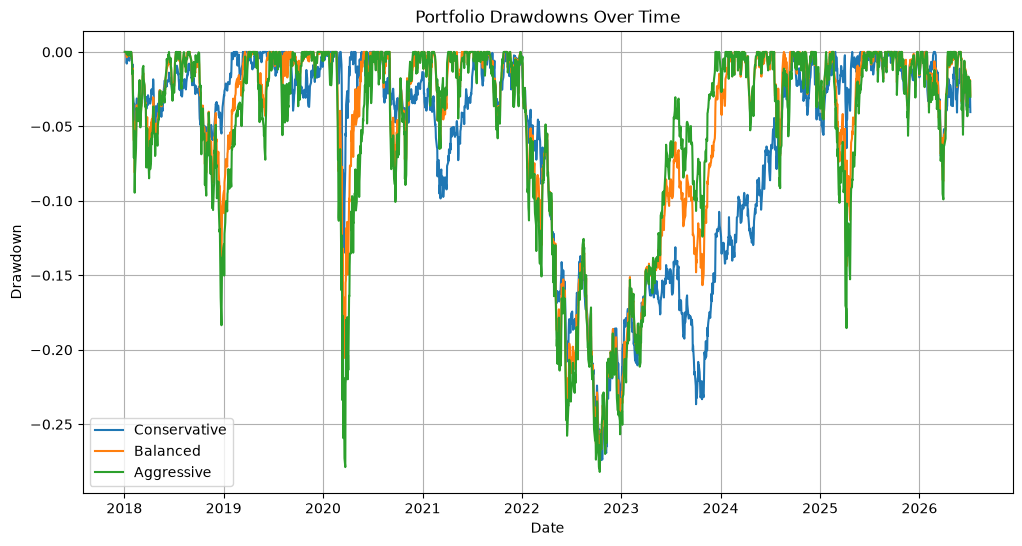

In [8]:
plt.figure(figsize=(12, 6))

for portfolio_name in drawdowns.columns:
    plt.plot(drawdowns.index, drawdowns[portfolio_name], label=portfolio_name)

plt.title("Portfolio Drawdowns Over Time")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)

plt.savefig(IMAGES_DIR / "portfolio_drawdowns.png", dpi=300, bbox_inches="tight")

plt.show()

## Historical Stress Period Analysis

In this section, we evaluate portfolio performance during selected historical stress periods available in the dataset.

Instead of using hypothetical shocks, this analysis uses actual historical daily returns.

In [9]:
# Historical stress periods available in the dataset
historical_stress_periods = {
    "Q4 2018 Sell-Off": ("2018-10-01", "2018-12-31"),
    "COVID Crash": ("2020-02-19", "2020-03-23"),
    "2022 Equity-Bond Sell-Off": ("2022-01-03", "2022-10-14")
}

historical_stress_periods

{'Q4 2018 Sell-Off': ('2018-10-01', '2018-12-31'),
 'COVID Crash': ('2020-02-19', '2020-03-23'),
 '2022 Equity-Bond Sell-Off': ('2022-01-03', '2022-10-14')}

In [10]:
# Calculate portfolio returns during historical stress periods
historical_stress_results = pd.DataFrame(index=historical_stress_periods.keys())

for period_name, (start_date, end_date) in historical_stress_periods.items():
    period_returns = portfolio_daily_returns.loc[start_date:end_date]

    cumulative_returns = (1 + period_returns).prod() - 1

    historical_stress_results.loc[period_name, cumulative_returns.index] = cumulative_returns

# Save results
historical_stress_results.to_csv(
    OUTPUTS_DIR / "historical_stress_period_returns.csv"
)

historical_stress_results

,Conservative,Balanced,Aggressive
Q4 2018 Sell-Off,-0.007563,-0.089563,-0.129349
COVID Crash,-0.038238,-0.199057,-0.274089
2022 Equity-Bond Sell-Off,-0.262125,-0.269341,-0.276436


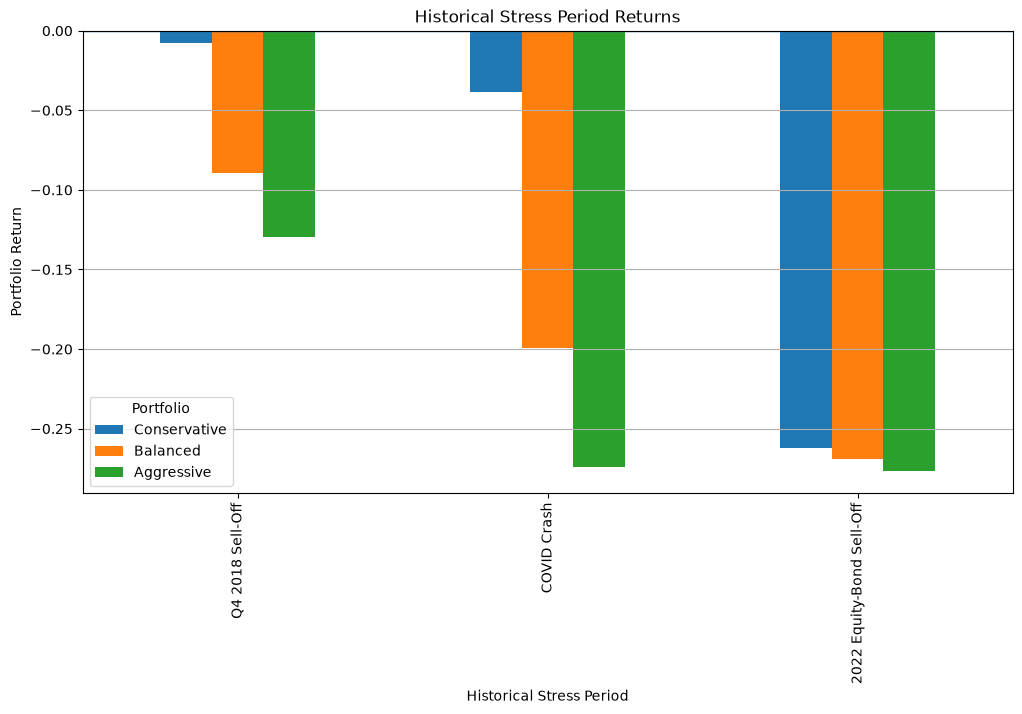

In [11]:
ax = historical_stress_results.plot(kind="bar", figsize=(12, 6))

plt.title("Historical Stress Period Returns")
plt.xlabel("Historical Stress Period")
plt.ylabel("Portfolio Return")
plt.axhline(0, linewidth=1)
plt.grid(axis="y")
plt.legend(title="Portfolio")

fig = ax.get_figure()
fig.savefig(IMAGES_DIR / "historical_stress_period_returns.png", dpi=300, bbox_inches="tight")

plt.show()

## Stress Testing Interpretation

The stress testing analysis shows how different portfolio allocations behave under both hypothetical and historical adverse market conditions.

The Conservative portfolio generally benefits from its larger allocation to Treasury bonds and gold, which may reduce losses during equity market downturns. However, it can still be negatively affected in scenarios where bonds decline sharply, such as a rate shock.

The Balanced portfolio shows intermediate behavior, with moderate exposure to equities and some diversification through bonds and gold.

The Aggressive portfolio is the most sensitive to equity market declines because of its high allocation to SPY and QQQ. It may perform better in strong equity markets, but it typically experiences larger losses during market stress.

Maximum drawdown analysis provides an additional risk perspective by showing the largest historical peak-to-trough decline for each portfolio.

## Rolling Volatility Analysis

Rolling volatility shows how portfolio risk changes over time.

We calculate 30-day rolling volatility and annualize it to compare risk across Conservative, Balanced, and Aggressive portfolios.

In [12]:
# Calculate 30-day rolling annualized volatility
rolling_window = 30

rolling_volatility = portfolio_daily_returns.rolling(
    window=rolling_window
).std() * np.sqrt(252)

# Save results
rolling_volatility.to_csv(
    OUTPUTS_DIR / "rolling_volatility_30d.csv"
)

rolling_volatility.tail()

,Conservative,Balanced,Aggressive
Date,,,
2026-06-30,0.123246,0.170788,0.199889
2026-07-01,0.123771,0.171683,0.200934
2026-07-02,0.121319,0.170551,0.200818
2026-07-06,0.117075,0.168470,0.199636
2026-07-07,0.120715,0.171391,0.202266


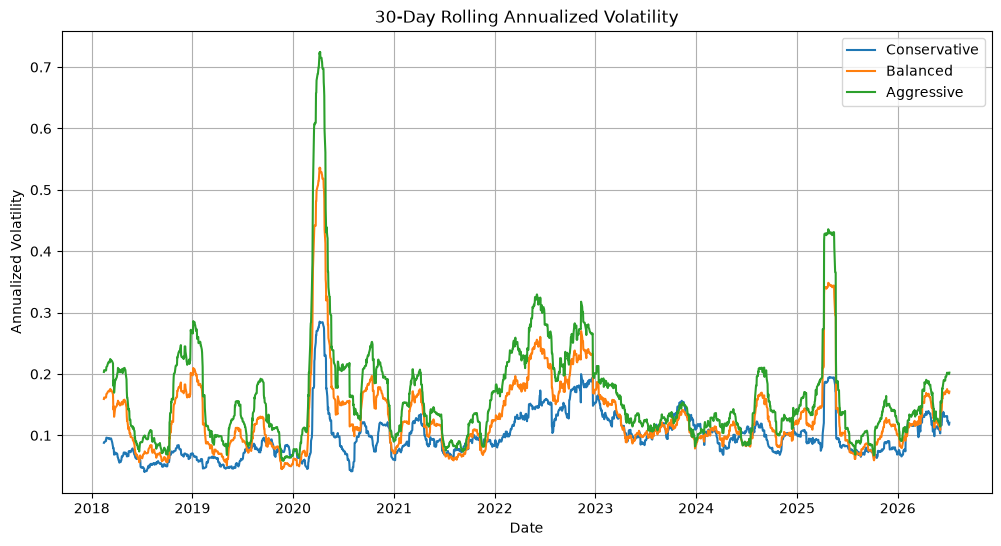

In [13]:
plt.figure(figsize=(12, 6))

for portfolio_name in rolling_volatility.columns:
    plt.plot(
        rolling_volatility.index,
        rolling_volatility[portfolio_name],
        label=portfolio_name
    )

plt.title("30-Day Rolling Annualized Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.grid(True)

plt.savefig(IMAGES_DIR / "rolling_volatility_30d.png", dpi=300, bbox_inches="tight")

plt.show()

## Worst Rolling Return Analysis

This section identifies the worst rolling 30-day and 60-day returns for each portfolio.

This helps measure short-term downside risk during difficult market periods.

In [14]:
# Calculate rolling cumulative returns
rolling_30d_returns = (1 + portfolio_daily_returns).rolling(30).apply(
    lambda x: np.prod(x) - 1,
    raw=True
)

rolling_60d_returns = (1 + portfolio_daily_returns).rolling(60).apply(
    lambda x: np.prod(x) - 1,
    raw=True
)

worst_rolling_returns = pd.DataFrame({
    "Worst 30-Day Return": rolling_30d_returns.min(),
    "Worst 60-Day Return": rolling_60d_returns.min()
})

# Save results
worst_rolling_returns.to_csv(
    OUTPUTS_DIR / "worst_rolling_returns.csv"
)

worst_rolling_returns

,Worst 30-Day Return,Worst 60-Day Return
Conservative,-0.125639,-0.153784
Balanced,-0.188637,-0.174079
Aggressive,-0.261084,-0.220492


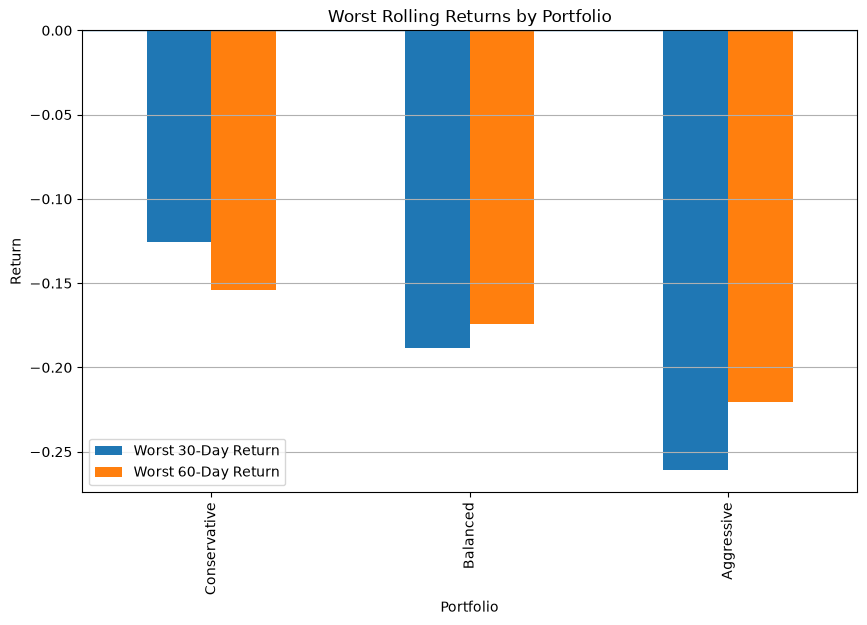

In [15]:
ax = worst_rolling_returns.plot(kind="bar", figsize=(10, 6))

plt.title("Worst Rolling Returns by Portfolio")
plt.xlabel("Portfolio")
plt.ylabel("Return")
plt.axhline(0, linewidth=1)
plt.grid(axis="y")

fig = ax.get_figure()
fig.savefig(IMAGES_DIR / "worst_rolling_returns.png", dpi=300, bbox_inches="tight")

plt.show()

## Rolling Risk Interpretation

The rolling volatility analysis shows that portfolio risk changes significantly over time, especially during market stress periods.

The Aggressive portfolio consistently displays the highest volatility because of its larger allocation to equities, especially QQQ and SPY.

The Conservative portfolio generally has the lowest rolling volatility, reflecting the stabilizing effect of Treasury bonds and gold.

The worst rolling return analysis shows the largest short-term losses experienced by each portfolio over 30-day and 60-day periods. These results highlight that downside risk can increase sharply during periods of market instability.

Overall, the stress testing notebook complements the Monte Carlo simulation by showing how portfolios behave under both hypothetical shocks and actual historical market stress.